In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

plt.ion()   

In [2]:
from six.moves import urllib
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training dataset
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='.', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])), batch_size=64, shuffle=True, num_workers=4)
# Test dataset
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='.', train=False, transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=64, shuffle=True, num_workers=4)

In [3]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

        # Spatial transformer localization-network
        self.localization = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=7),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True)
        )

        # Regressor for the 3 * 2 affine matrix
        self.fc_loc = nn.Sequential(
            nn.Linear(10 * 3 * 3, 32),
            nn.ReLU(True),
            nn.Linear(32, 3 * 2)
        )

        # Initialize the weights/bias with identity transformation
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    # Spatial transformer network forward function
    def stn(self, x):
        xs = self.localization(x)
        xs = xs.view(-1, 10 * 3 * 3)
        theta = self.fc_loc(xs)
        theta = theta.view(-1, 2, 3)

        grid = F.affine_grid(theta, x.size())
        x = F.grid_sample(x, grid)

        return x

    def forward(self, x):
        # transform the input
        x = self.stn(x)

        # Perform the usual forward pass
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


model = Net().to(device)

In [ ]:
batchidx, (data, target) train_loader

ValueError: too many values to unpack (expected 2)

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 500 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
#
# A simple test procedure to measure the STN performances on MNIST.
#


def test():
    with torch.no_grad():
        model.eval()
        test_loss = 0
        correct = 0
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # sum up batch loss
            test_loss += F.nll_loss(output, target, size_average=False).item()
            # get the index of the max log-probability
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()

        test_loss /= len(test_loader.dataset)
        print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'
              .format(test_loss, correct, len(test_loader.dataset),
                      100. * correct / len(test_loader.dataset)))

/home/shooty/anaconda3/envs/ds-env-04/lib/python3.13/site-packages/torch/nn/functional.py:5082: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/home/shooty/anaconda3/envs/ds-env-04/lib/python3.13/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.304046
Train Epoch: 1 [32000/60000 (53%)]	Loss: 1.032660


/home/shooty/anaconda3/envs/ds-env-04/lib/python3.13/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Average loss: 0.2481, Accuracy: 9296/10000 (93%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.432235
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.282428

Test set: Average loss: 0.1291, Accuracy: 9596/10000 (96%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.189569
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.228568

Test set: Average loss: 0.1275, Accuracy: 9630/10000 (96%)

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.259263
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.133193

Test set: Average loss: 0.0907, Accuracy: 9704/10000 (97%)

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.251225
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.190504

Test set: Average loss: 0.0727, Accuracy: 9777/10000 (98%)

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.115208
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.158797

Test set: Average loss: 0.0694, Accuracy: 9790/10000 (98%)

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.408879
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.250747

Test set: Average loss: 0.0595, Accuracy: 9809/10000 (98%)

Tra

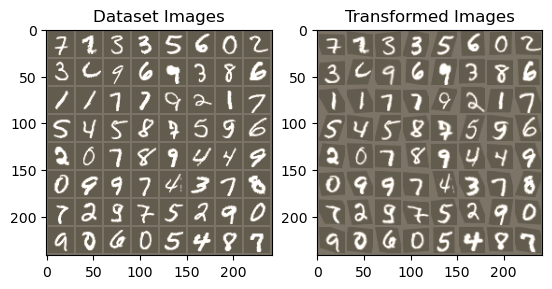

In [5]:
def convert_image_np(inp):
    """Convert a Tensor to numpy image."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    return inp

# We want to visualize the output of the spatial transformers layer
# after the training, we visualize a batch of input images and
# the corresponding transformed batch using STN.


def visualize_stn():
    with torch.no_grad():
        # Get a batch of training data
        data = next(iter(test_loader))[0].to(device)

        input_tensor = data.cpu()
        transformed_input_tensor = model.stn(data).cpu()

        in_grid = convert_image_np(
            torchvision.utils.make_grid(input_tensor))

        out_grid = convert_image_np(
            torchvision.utils.make_grid(transformed_input_tensor))

        # Plot the results side-by-side
        f, axarr = plt.subplots(1, 2)
        axarr[0].imshow(in_grid)
        axarr[0].set_title('Dataset Images')

        axarr[1].imshow(out_grid)
        axarr[1].set_title('Transformed Images')

for epoch in range(1, 20 + 1):
    train(epoch)
    test()

# Visualize the STN transformation on some input batch
visualize_stn()

plt.ioff()
plt.show()

In [84]:
import zarr
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class DCEZarrDataset(Dataset):
    def __init__(self, input_path, target_path):
        self.input_zarr = da.from_zarr(input_path)
        self.target_zarr = da.from_zarr(target_path)
        self.length = self.input_zarr.shape[3]  # Anzahl Zeitpunkte

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        input_vol = self.input_zarr[:, :, :, idx].astype(np.float32).compute()
        target_vol = self.target_zarr[:, :, :, idx].astype(np.float32).compute()

        # (256, 256, 50) → (50, 256, 256) → (1, 1, 50, 256, 256)
        input_vol = np.transpose(input_vol, (2, 0, 1))
        target_vol = np.transpose(target_vol, (2, 0, 1))

        input_tensor = torch.from_numpy(input_vol).unsqueeze(0)
        target_tensor = torch.from_numpy(target_vol).unsqueeze(0).unsqueeze(0)

        return input_tensor, target_tensor


In [85]:
class STN3D(nn.Module):
    def __init__(self):
        super(STN3D, self).__init__()

        self.localization = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool3d(2),  # z.B. (12, 64, 64) -> (6, 32, 32)
            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool3d(2),  # z.B. -> (3, 16, 16)
        )

        # Dynamische Größenberechnung anhand eines DUMMY-Inputs
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 50, 256, 256)
            out = self.localization(dummy)
            self.flattened_size = out.view(1, -1).shape[1]

        self.fc_loc = nn.Sequential(
            nn.Linear(self.flattened_size, 128),
            nn.ReLU(True),
            nn.Linear(128, 12)
        )

        # Init auf Identitätsmatrix
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(
            torch.tensor([1, 0, 0, 0,
                          0, 1, 0, 0,
                          0, 0, 1, 0], dtype=torch.float)
        )

    def stn(self, x):
        xs = self.localization(x)
        xs = xs.view(xs.size(0), -1)
        theta = self.fc_loc(xs).view(-1, 3, 4)

        grid = F.affine_grid(theta, x.size(), align_corners=True)
        x = F.grid_sample(x, grid, align_corners=True)
        return x

    def forward(self, x):
        return self.stn(x)


In [86]:
import dask.array as da
coreg_set = da.from_zarr('/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr')
DCE_set = da.from_zarr('/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE')

In [87]:
coreg_set

dask.array<from-zarr, shape=(256, 256, 50, 1000), dtype=float32, chunksize=(256, 256, 1, 1), chunktype=numpy.ndarray>

In [88]:
DCE_set

dask.array<from-zarr, shape=(256, 256, 50, 1000), dtype=float32, chunksize=(256, 256, 1, 1), chunktype=numpy.ndarray>

In [89]:
from tqdm import tqdm

def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    dataset = DCEZarrDataset('/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE', '/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr')
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

    model = STN3D().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.MSELoss()

    num_epochs = 10

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

        for x, y in progress:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress.set_postfix(loss=loss.item())

        print(f"[Epoch {epoch+1}] Avg. Loss: {epoch_loss / len(dataloader):.6f}")


In [90]:
train()

cuda


Epoch 1/10:   0%|          | 0/1000 [00:00<?, ?batch/s]/home/shooty/anaconda3/envs/ds-env-04/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1, 1, 50, 256, 256])) that is different to the input size (torch.Size([1, 1, 50, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1/10: 100%|██████████| 1000/1000 [03:10<00:00,  5.26batch/s, loss=1.91e+5]


[Epoch 1] Avg. Loss: 190567.755913


Epoch 2/10: 100%|██████████| 1000/1000 [03:15<00:00,  5.12batch/s, loss=1.93e+5]


[Epoch 2] Avg. Loss: 196511.547781


...

[Epoch 8] Avg. Loss: 196511.547781


Epoch 9/10: 100%|██████████| 1000/1000 [03:10<00:00,  5.25batch/s, loss=1.99e+5]


[Epoch 9] Avg. Loss: 196511.547781


Epoch 10/10: 100%|██████████| 1000/1000 [03:02<00:00,  5.47batch/s, loss=2.07e+5]

[Epoch 10] Avg. Loss: 196511.547781


In [ ]:
import matplotlib.pyplot as plt

def show_registration(moving, fixed, registered, slice_idx=20):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(moving[0, 0, slice_idx].detach().cpu(), cmap='gray')
    axs[0].set_title("Moving")
    axs[1].imshow(fixed[0, 0, slice_idx].detach().cpu(), cmap='gray')
    axs[1].set_title("Fixed")
    axs[2].imshow(registered[0, 0, slice_idx].detach().cpu(), cmap='gray')
    axs[2].set_title("Registered")
    plt.tight_layout()
    plt.show()
